## Dataset REVIEWS
[Kaggle Link](https://www.kaggle.com/competitions/184-702-tu-ml-2025-w-reviews/overview)

### Imports

todo in code: remove ifs i did while debugging, clean code, document ig? -> create the docs

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-learn: model selection / CV
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    KFold,
    train_test_split
)

# Scikit-learn: preprocessing
from sklearn.preprocessing import StandardScaler

# Scikit-learn: feature selection & decomposition
from sklearn.feature_selection import (
    SelectKBest,
    SelectFromModel,
    f_classif,
)

# Scikit-learn: models / estimators
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Scikit-learn: pipeline & metrics
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [3]:
# Add the parent directory to sys.path to be able to import own packages from outside the notebooks directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
# Local project modules
from src.utils import * 
from src.evaluation import *

In [4]:
# Load the data and catch a quick glimpse.
curr_dir = os.getcwd()

# Load the given training and test data sets
train_path = os.path.join(curr_dir, '..', 'data', 'reviews/amazon_review_ID.shuf.lrn.csv') # training data, for excercise it was used as a 0.8-0.2 train test split, for kagle whole thing as training data
test_path = os.path.join(curr_dir, '..', 'data', 'reviews/amazon_review_ID.shuf.tes.csv') # final test data, for kaggle submission
ytest_path = os.path.join(curr_dir, '..', 'data', 'reviews/amazon_review_ID.shuf.sol.ex.csv') # true labels for final test data, for evaluation

train_df = pd.read_csv(train_path)
final_test_df = pd.read_csv(test_path)
y_test_kaggle = pd.read_csv(ytest_path)

train_df.shape, final_test_df.shape,


((750, 10002), (750, 10001))

### Section for kaggle, new train/test + new parameters


 Starting FINETUNED SVM Search (Linear + RBF) 
Fitting 10 folds for each of 25 candidates, totalling 250 fits

 SVM Search Complete 
Best SVM Score (CV Accuracy): 0.6667
Best SVM Parameters Found:
{'scaler': StandardScaler(), 'selector__k': 1500, 'svm__C': 0.01, 'svm__kernel': 'linear'}

Best CV accuracy per scaler (overall):
      scaler_name  mean_test_score
0  StandardScaler         0.666667


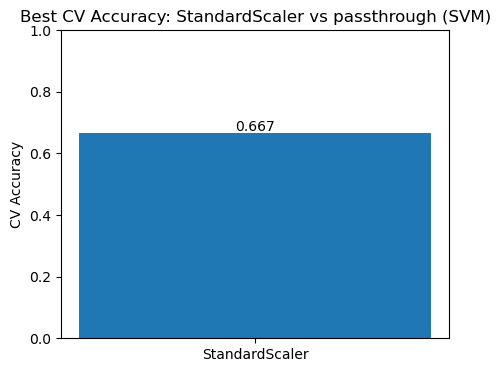

In [5]:

# Best SVM Parameters Found:
# {'scaler': StandardScaler(), 'selector__k': 150, 'svm__C': 0.05, 'svm__kernel': 'linear'}
target_column = 'Class'
X_k, y_k = train_df.drop(columns=[target_column]), train_df[target_column]
X_final_test_k = final_test_df
y_final_test_k = y_test_kaggle[target_column]

X_k.shape, y_k.shape, X_final_test_k.shape
kfold_cv = KFold(n_splits=10, shuffle=True, random_state=42)

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('svm', SVC(probability=True, random_state=42)) 
])


#  param grids (add scaler choice to both) 
param_grid_linear = {
    'scaler': [StandardScaler()],
    'selector__k': [500, 1000, 1500, 1700, 2000],
    'svm__kernel': ['linear'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10]
}

print("\n Starting FINETUNED SVM Search (Linear + RBF) ")
# We pass the list of grids to the 'param_grid' argument
grid_svm = GridSearchCV(
    pipeline_svm,
    [param_grid_linear],
    cv=kfold_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)
grid_svm.fit(X_k, y_k)
print("\n SVM Search Complete ")
print(f"Best SVM Score (CV Accuracy): {grid_svm.best_score_:.4f}")
print("Best SVM Parameters Found:")
print(grid_svm.best_params_)

#    extract cv results into DataFrame for plotting/analysis   
cv = pd.DataFrame(grid_svm.cv_results_)

cv['scaler_name'] = 'StandardScaler'
cv['C'] = cv['param_svm__C'].astype(float)
cv['kernel'] = cv['param_svm__kernel'].astype(str)
cv['selector_k'] = cv['param_selector__k'].astype(int)
cv['mean_test_score'] = cv['mean_test_score'].astype(float)

# 1) Best CV accuracy per scaler (overall, across kernels and other params)
best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy per scaler (overall):")
print(best_per_scaler)

# bar plot: best per scaler
plt.figure(figsize=(5,4))
plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
plt.ylim(0,1)
plt.ylabel('CV Accuracy')
plt.title('Best CV Accuracy: StandardScaler vs passthrough (SVM)')
for i, v in enumerate(best_per_scaler['mean_test_score']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()


best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_final_test_k)

y_pred_svm
results = pd.Series(y_pred_svm, name='Class')
ids = np.arange(750, 750 + len(y_pred_svm))
results_df = pd.DataFrame({
    'id': ids,
    'Class': y_pred_svm
})
results_df.to_csv('svm_predictions_with_id.csv', index=False)

### Dataset exploration

In [10]:
target_column = 'Class'
X, y = train_df.drop(columns=[target_column]), train_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
kfold_cv = KFold(n_splits=10, shuffle=True, random_state=42)

Numeric feature balance:
              mean         std  min    max      skew
ID      374.500000  216.650640  0.0  749.0  0.000000
V1       11.612000    5.424576  0.0   32.0  0.564004
V2        7.317333    3.521150  0.0   19.0  0.395602
V3        6.724000    3.330457  0.0   20.0  0.469128
V4        6.385333    3.698164  0.0   20.0  0.691829
...            ...         ...  ...    ...       ...
V9996     0.225333    0.504874  0.0    3.0  2.448257
V9997     0.190667    0.458905  0.0    3.0  2.653711
V9998     0.208000    0.489614  0.0    4.0  2.819564
V9999     0.208000    0.470139  0.0    3.0  2.292388
V10000    0.216000    0.581201  0.0    4.0  3.371778

[10001 rows x 5 columns]

Categorical: Class
Class
Sherwin        0.027
Chachra        0.025
Wilson         0.025
Power          0.025
Comdet         0.025
Davisson       0.024
Merritt        0.024
Chell          0.024
Hayes          0.024
Brody          0.023
Chandler       0.023
Corn           0.021
Cholette       0.021
Blankenship   

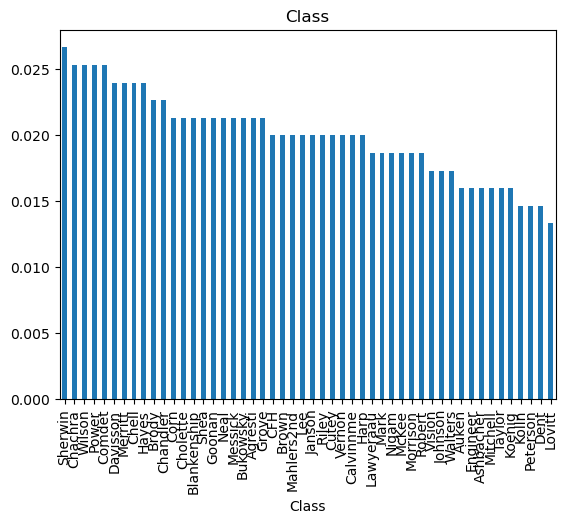

In [11]:
def check_feature_balance(df, bins=20):
    num_cols = df.select_dtypes(include=['number']).columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    print("Numeric feature balance:")
    print(df[num_cols].agg(['mean','std','min','max','skew']).T)
    
    for col in cat_cols:
        print(f"\nCategorical: {col}")
        print(df[col].value_counts(normalize=True).round(3))
        df[col].value_counts(normalize=True).plot(kind='bar', title=col)
        plt.show()
check_feature_balance(train_df)

In [12]:
feature_ranges = train_df.drop(columns=[target_column]).max() - train_df.drop(columns=[target_column]).min()

# Sort and inspect
feature_ranges.sort_values(ascending=False)

ID       749
V6567    362
V6568    174
V6569    120
V6570    112
        ... 
V6286      1
V6284      1
V6283      1
V6282      1
V5000      1
Length: 10001, dtype: int64

In [13]:
# helper method for plotting
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except:
        return str(x)

In [14]:
# Function to analyze a fitted GridSearchCV object 
def analyze_grid_knn_fsc(grid, title_prefix=''):
    cv = pd.DataFrame(grid.cv_results_)
    # add readable scaler column
    cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
    # add n_neighbors if present
    #if 'param_knn__n_neighbors' in cv.columns:
    cv['n_neighbors'] = pd.to_numeric(cv['param_knn__n_neighbors'], errors='coerce').astype('Int64')
    #else:
        #cv['n_neighbors'] = np.nan

    # Summaries
    best_score = grid.best_score_
    best_params = grid.best_params_
    print(f"\n {title_prefix} Summary ")
    print("Best CV score:", best_score)
    print("Best params:", best_params)

    # 1) Best CV accuracy per scaler
    best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
    print("\nBest CV accuracy per scaler:")
    print(best_per_scaler)

    plt.figure(figsize=(5,4))
    plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
    plt.ylim(0,1)
    plt.ylabel('CV Accuracy')
    plt.title(f'{title_prefix}: Best CV Accuracy per scaler')
    for i, v in enumerate(best_per_scaler['mean_test_score']):
        plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
    plt.tight_layout()
    plt.show()

    agg = cv.groupby(['scaler_name', 'n_neighbors'])['mean_test_score'].max().unstack('scaler_name')
    plt.figure(figsize=(7,4))
    for col in agg.columns:
        plt.plot(agg.index.astype(float), agg[col], marker='o', label=col)
    plt.xlabel('n_neighbors')
    plt.ylabel('CV Accuracy')
    plt.title(f'{title_prefix}: CV Accuracy vs n_neighbors (by scaler)')
    plt.legend(title='scaler')
    plt.grid(alpha=0.2)
    plt.show()

    # 3) Show top configurations
    top = cv.sort_values('mean_test_score', ascending=False).head(10)
    cols_show = ['mean_test_score', 'param_scaler', 'param_knn__n_neighbors']
    # some grids have selector__k
    if 'param_selector__k' in cv.columns:
        cols_show.append('param_selector__k')
    print("\nTop CV configurations (head):")
    print(top[cols_show].to_string(index=False))

    # 4) For the best estimator (GridSearchCV refitted), report selected feature count if selector has get_support
    best_pipe = grid.best_estimator_
    sel = best_pipe.named_steps.get('selector', None)
    sel_count = None
    try:
        if sel == 'passthrough' or sel is None:
            sel_count = X_train.shape[1]
        elif hasattr(sel, 'get_support'):
            sel_mask = sel.get_support()
            sel_count = int(sel_mask.sum())
        elif hasattr(sel, 'n_features_'):
            sel_count = int(sel.n_features_)
    except Exception:
        sel_count = None
    print(f"\nSelected feature count for best pipeline (if available): {sel_count}")


    return cv, best_pipe

# KNN

#### KNN Feature selection experiment


 Running GridSearch for SelectKBest (f_classif)
Fitting 10 folds for each of 40 candidates, totalling 400 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Done SelectKBest search.
Best CV score: 0.4583333333333333
Best params: {'knn__n_neighbors': 7, 'scaler': StandardScaler(), 'selector__k': 200}

Running GridSearch for SelectFromModel(RandomForest)
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Done SelectFromModel(RF) search.
Best CV score: 0.10333333333333335
Best params: {'knn__n_neighbors': 3, 'scaler': StandardScaler()}

Running GridSearch for Passthrough (no selection)
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Done passthrough search.
Best CV score: 0.07500000000000001
Best params: {'knn__n_neighbors': 3, 'scaler': 'passthrough'}

 SelectKBest_f_classif Summary 
Best CV score: 0.4583333333333333
Best params: {'knn__n_neighbors': 7, 'scaler': StandardScaler(), 'selector__k': 200}

Best CV accuracy per scaler:
      scaler_name  mean_test_score
0  StandardScaler         0.458333
1     passthrough         0.208333


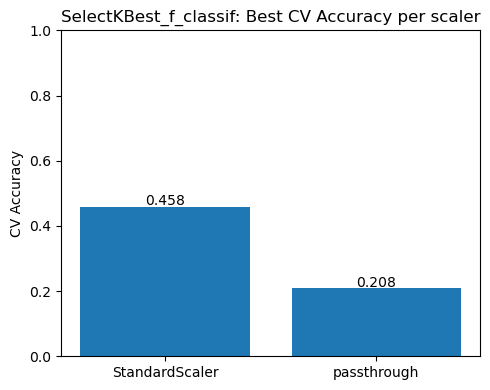

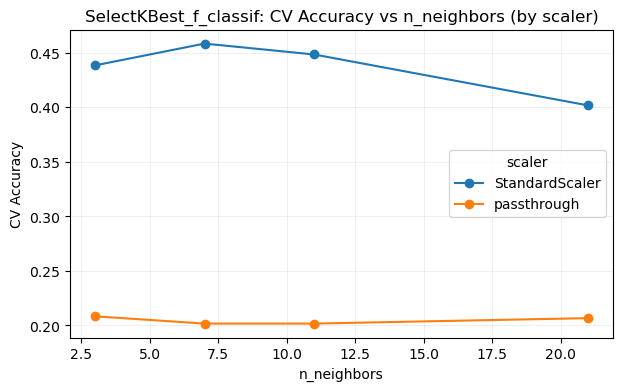


Top CV configurations (head):
 mean_test_score     param_scaler  param_knn__n_neighbors  param_selector__k
        0.458333 StandardScaler()                       7                200
        0.455000 StandardScaler()                       7                100
        0.448333 StandardScaler()                      11                100
        0.438333 StandardScaler()                       3                200
        0.436667 StandardScaler()                       3                100
        0.425000 StandardScaler()                      11                200
        0.408333 StandardScaler()                       7                300
        0.405000 StandardScaler()                       7                 50
        0.403333 StandardScaler()                       3                300
        0.401667 StandardScaler()                      21                100

Selected feature count for best pipeline (if available): 200

 SelectFromModel_RF Summary 
Best CV score: 0.1033333333333

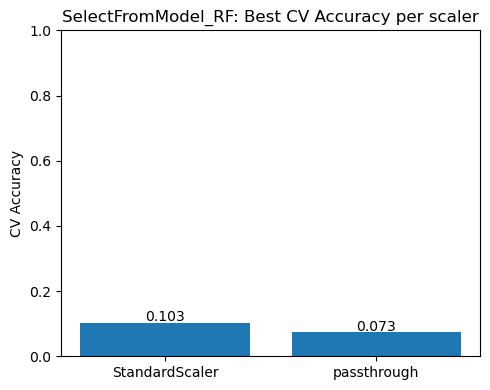

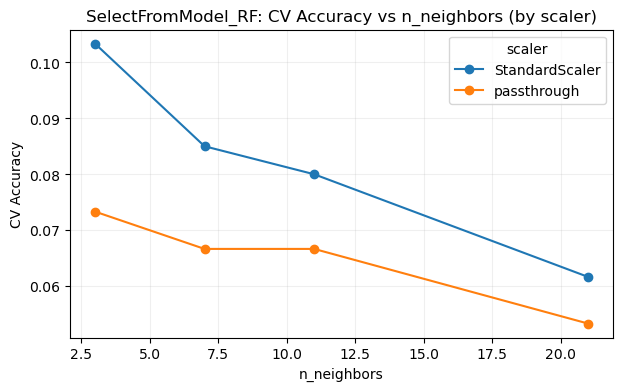


Top CV configurations (head):
 mean_test_score     param_scaler  param_knn__n_neighbors
        0.103333 StandardScaler()                       3
        0.085000 StandardScaler()                       7
        0.080000 StandardScaler()                      11
        0.073333      passthrough                       3
        0.066667      passthrough                       7
        0.066667      passthrough                      11
        0.061667 StandardScaler()                      21
        0.053333      passthrough                      21

Selected feature count for best pipeline (if available): 5001

 Passthrough Summary 
Best CV score: 0.07500000000000001
Best params: {'knn__n_neighbors': 3, 'scaler': 'passthrough'}

Best CV accuracy per scaler:
      scaler_name  mean_test_score
1     passthrough         0.075000
0  StandardScaler         0.043333


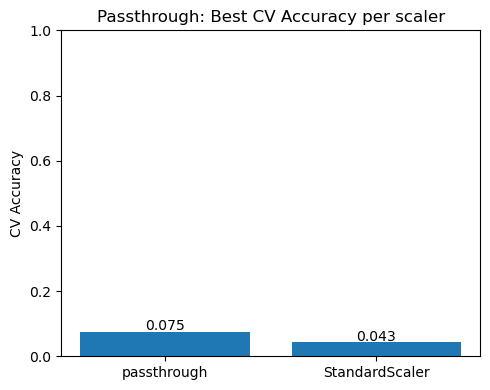

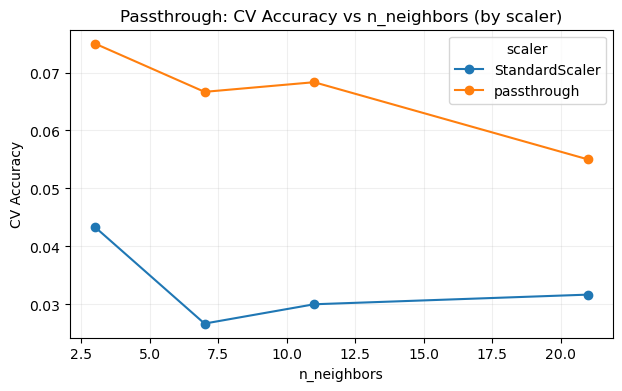


Top CV configurations (head):
 mean_test_score     param_scaler  param_knn__n_neighbors
        0.075000      passthrough                       3
        0.068333      passthrough                      11
        0.066667      passthrough                       7
        0.055000      passthrough                      21
        0.043333 StandardScaler()                       3
        0.031667 StandardScaler()                      21
        0.030000 StandardScaler()                      11
        0.026667 StandardScaler()                       7

Selected feature count for best pipeline (if available): 10001


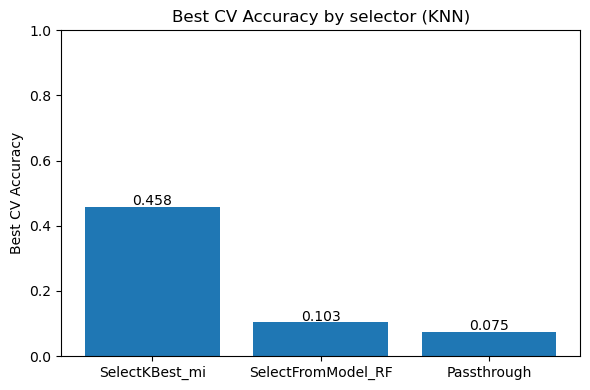

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


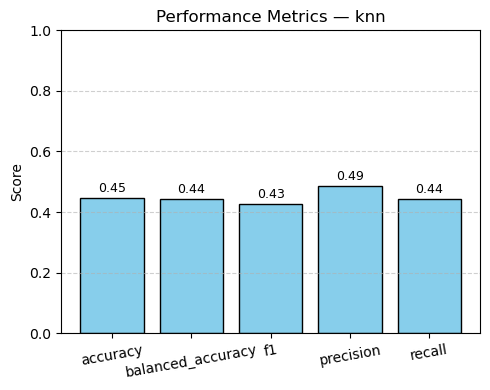

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


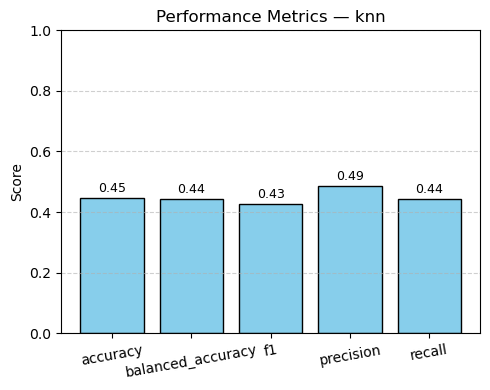

In [ ]:

# section for feature selection comparison

# 1) Pipeline: SelectKBest(f_classif)
pipeline_skb = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('knn', KNeighborsClassifier())
])

param_grid_skb = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 100, 200, 300, 400],
    'knn__n_neighbors': [3, 7, 11, 21]
}

print("\n Running GridSearch for SelectKBest (f_classif)")
grid_skb = GridSearchCV(pipeline_skb, param_grid_skb, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_skb.fit(X_train, y_train)
print("Done SelectKBest search.")
print("Best CV score:", grid_skb.best_score_)
print("Best params:", grid_skb.best_params_)


#  2) Pipeline: SelectFromModel(RandomForest) 
rf_for_sel = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
pipeline_sfm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(estimator=rf_for_sel, threshold='median')),
    ('knn', KNeighborsClassifier())
])

param_grid_sfm = {
    'scaler': [StandardScaler(), 'passthrough'],
    'knn__n_neighbors': [3, 7, 11, 21]
}

print("\nRunning GridSearch for SelectFromModel(RandomForest)")
grid_sfm = GridSearchCV(pipeline_sfm, param_grid_sfm, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_sfm.fit(X_train, y_train)
print("Done SelectFromModel(RF) search.")
print("Best CV score:", grid_sfm.best_score_)
print("Best params:", grid_sfm.best_params_)


# 3) Pipeline: passthrough (no selection) 
pipeline_passthrough = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', 'passthrough'),
    ('knn', KNeighborsClassifier())
])

param_grid_pass = {
    'scaler': [StandardScaler(), 'passthrough'],
    'knn__n_neighbors': [3, 7, 11, 21]
}

print("\nRunning GridSearch for Passthrough (no selection)")
grid_pass = GridSearchCV(pipeline_passthrough, param_grid_pass, cv=kfold_cv,
                         scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_pass.fit(X_train, y_train)
print("Done passthrough search.")
print("Best CV score:", grid_pass.best_score_)
print("Best params:", grid_pass.best_params_)



#   Analyze each grid separately  
cv_skb, best_pipe_skb = analyze_grid_knn_fsc(grid_skb, title_prefix='SelectKBest_f_classif')
cv_sfm, best_pipe_sfm = analyze_grid_knn_fsc(grid_sfm, title_prefix='SelectFromModel_RF')
cv_pass, best_pipe_pass = analyze_grid_knn_fsc(grid_pass, title_prefix='Passthrough')

#   Optional: Combined comparison bar chart (best CV per selector)  
best_scores = pd.DataFrame({
    'selector': ['SelectKBest_mi', 'SelectFromModel_RF', 'Passthrough'],
    'best_cv': [grid_skb.best_score_, grid_sfm.best_score_, grid_pass.best_score_]
}).sort_values('best_cv', ascending=False)

plt.figure(figsize=(6,4))
plt.bar(best_scores['selector'], best_scores['best_cv'])
plt.ylim(0,1)
plt.ylabel('Best CV Accuracy')
plt.title('Best CV Accuracy by selector (KNN)')
for i, v in enumerate(best_scores['best_cv']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

# Final evaluation on test set using best found model (from SelectKBest)
best_knn = grid_skb.best_estimator_
y_pred_knn = best_knn.predict(X_test)
evaluation = evaluate_run(name='knn', y_true=y_test, y_pred=y_pred_knn, task_type='classification')
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)


## SVM

In [20]:
#   Function to analyze a fitted GridSearchCV object  
def analyze_grid_svm(grid, title_prefix=''):
    cv = pd.DataFrame(grid.cv_results_)
    cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
    # add selector k if present
    if 'param_selector__k' in cv.columns:
        cv['selector__k'] = pd.to_numeric(cv['param_selector__k'], errors='coerce')
    top = cv.sort_values('mean_test_score', ascending=False).head(10)
    print(f"\nTop 10 CV configurations for {title_prefix}:")
    cols_show = ['mean_test_score', 'param_scaler', 'param_selector__k', 'param_svm__C', 'param_svm__kernel']
    cols_show = [c for c in cols_show if c in top.columns]
    print(top[cols_show].to_string(index=False))
    return cv

### Section for feature selection options


   Running GridSearch for SelectKBest (f_classif)   
Fitting 10 folds for each of 9 candidates, totalling 90 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Done SelectKBest search.
Best CV score: 0.625
Best params: {'scaler': StandardScaler(), 'selector__k': 200, 'svm__C': 0.1, 'svm__kernel': 'linear'}

   Running GridSearch for SelectFromModel(RandomForest)   
Fitting 10 folds for each of 3 candidates, totalling 30 fits
Done SelectFromModel(RF) search.
Best CV score: 0.5866666666666667
Best params: {'scaler': StandardScaler(), 'svm__C': 0.1, 'svm__kernel': 'linear'}

   Running GridSearch for Passthrough (no selection)   
Fitting 10 folds for each of 3 candidates, totalling 30 fits
Done passthrough search.
Best CV score: 0.5066666666666666
Best params: {'scaler': StandardScaler(), 'svm__C': 0.1, 'svm__kernel': 'linear'}

Top 10 CV configurations for SelectKBest_f_classif:
 mean_test_score     param_scaler  param_selector__k  param_svm__C param_svm__kernel
        0.625000 StandardScaler()                200           0.1            linear
        0.625000 StandardScaler()                200           1.0            linear
        0.62500

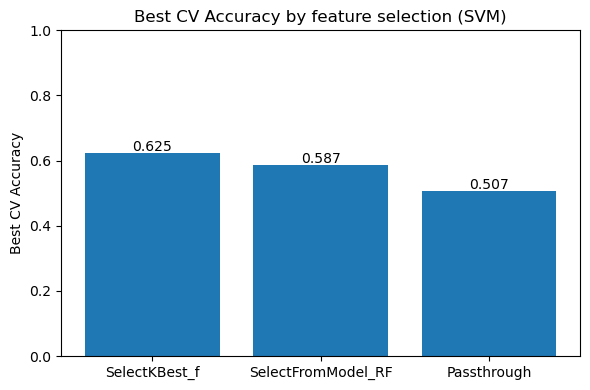

In [ ]:


#   1) Pipeline: SelectKBest (f_classif)  
pipeline_skb = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid_skb = {
    'scaler': [StandardScaler()],
    'selector__k': [100, 200, 300],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear']
}

print("\n   Running GridSearch for SelectKBest (f_classif)   ")
grid_skb = GridSearchCV(pipeline_skb, param_grid_skb, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_skb.fit(X_train, y_train)
print("Done SelectKBest search.")
print("Best CV score:", grid_skb.best_score_)
print("Best params:", grid_skb.best_params_)


#   2) Pipeline: SelectFromModel (RandomForest)  
rf_for_sel = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
pipeline_sfm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(estimator=rf_for_sel, threshold='median')),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid_sfm = {
    'scaler': [StandardScaler()],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear']
}

print("\n   Running GridSearch for SelectFromModel(RandomForest)   ")
grid_sfm = GridSearchCV(pipeline_sfm, param_grid_sfm, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_sfm.fit(X_train, y_train)
print("Done SelectFromModel(RF) search.")
print("Best CV score:", grid_sfm.best_score_)
print("Best params:", grid_sfm.best_params_)


#   3) Pipeline: passthrough (no selection)  
pipeline_pass = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', 'passthrough'),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid_pass = {
    'scaler': [StandardScaler()],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear']
}

print("\n   Running GridSearch for Passthrough (no selection)   ")
grid_pass = GridSearchCV(pipeline_pass, param_grid_pass, cv=kfold_cv,
                         scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_pass.fit(X_train, y_train)
print("Done passthrough search.")
print("Best CV score:", grid_pass.best_score_)
print("Best params:", grid_pass.best_params_)



#   Analyze each grid separately  
cv_skb = analyze_grid_svm(grid_skb, title_prefix='SelectKBest_f_classif')
cv_sfm = analyze_grid_svm(grid_sfm, title_prefix='SelectFromModel_RF')
cv_pass = analyze_grid_svm(grid_pass, title_prefix='Passthrough')

#   Optional: Combined comparison bar chart  
best_scores = pd.DataFrame({
    'selector': ['SelectKBest_f', 'SelectFromModel_RF', 'Passthrough'],
    'best_cv': [grid_skb.best_score_, grid_sfm.best_score_, grid_pass.best_score_]
}).sort_values('best_cv', ascending=False)

plt.figure(figsize=(6,4))
plt.bar(best_scores['selector'], best_scores['best_cv'])
plt.ylim(0,1)
plt.ylabel('Best CV Accuracy')
plt.title('Best CV Accuracy by feature selection (SVM)')
for i, v in enumerate(best_scores['best_cv']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

### Best feature selection + various parameters


 Starting FINETUNED SVM Search (Linear + RBF) 
Fitting 10 folds for each of 300 candidates, totalling 3000 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



 SVM Search Complete 
Best SVM Score (CV Accuracy): 0.6250
Best SVM Parameters Found:
{'scaler': StandardScaler(), 'selector__k': 150, 'svm__C': 0.05, 'svm__kernel': 'linear'}

Best CV accuracy per scaler (overall):
      scaler_name  mean_test_score
0  StandardScaler            0.625
1     passthrough            0.445


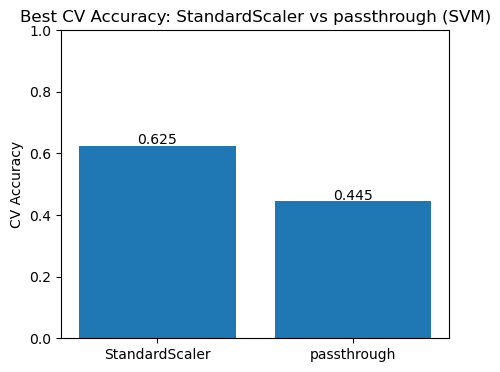

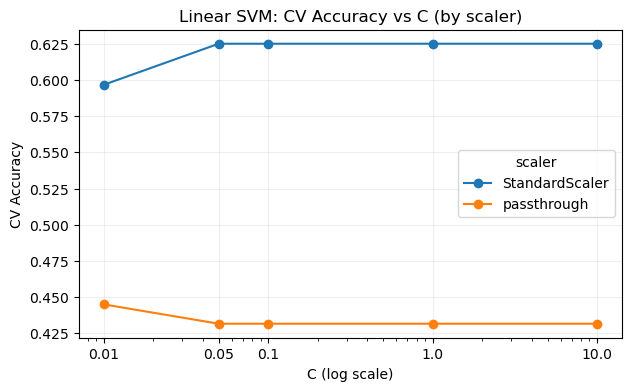


Linear kernel: best accuracy by (scaler, C):
scaler_name
StandardScaler    0.625
passthrough       0.445
dtype: float64


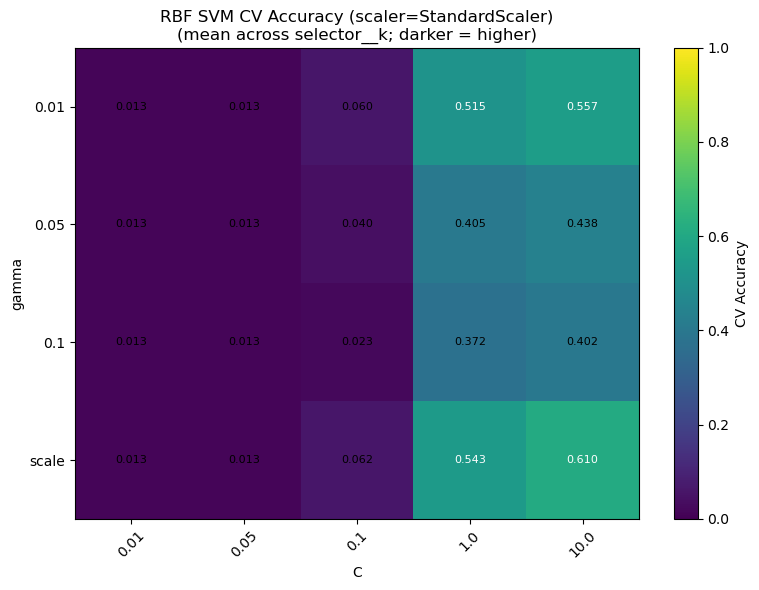

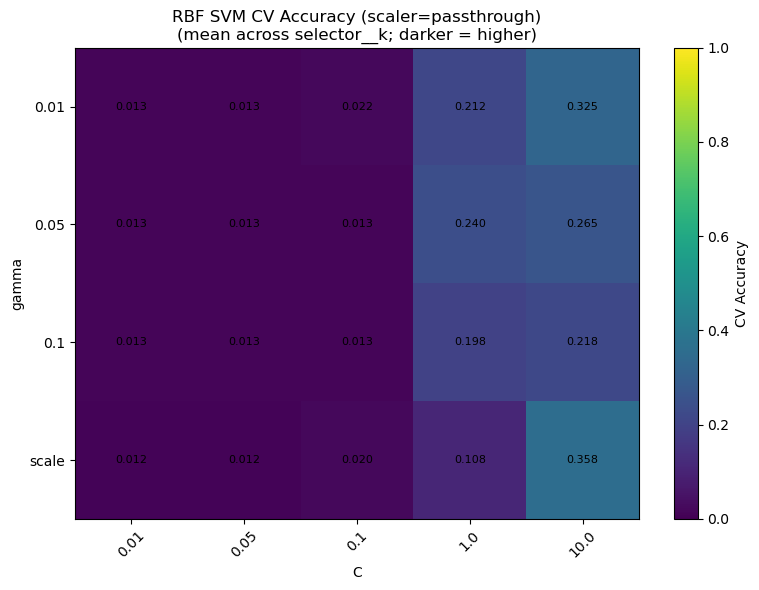


Top RBF configurations (scaler, gamma, C) by CV accuracy:
       scaler_name gamma_str     C  mean_test_score
19  StandardScaler     scale  10.0         0.610000
4   StandardScaler      0.01  10.0         0.556667
18  StandardScaler     scale   1.0         0.543333
3   StandardScaler      0.01   1.0         0.515000
9   StandardScaler      0.05  10.0         0.438333
8   StandardScaler      0.05   1.0         0.405000
14  StandardScaler       0.1  10.0         0.401667
13  StandardScaler       0.1   1.0         0.371667
39     passthrough     scale  10.0         0.358333
24     passthrough      0.01  10.0         0.325000


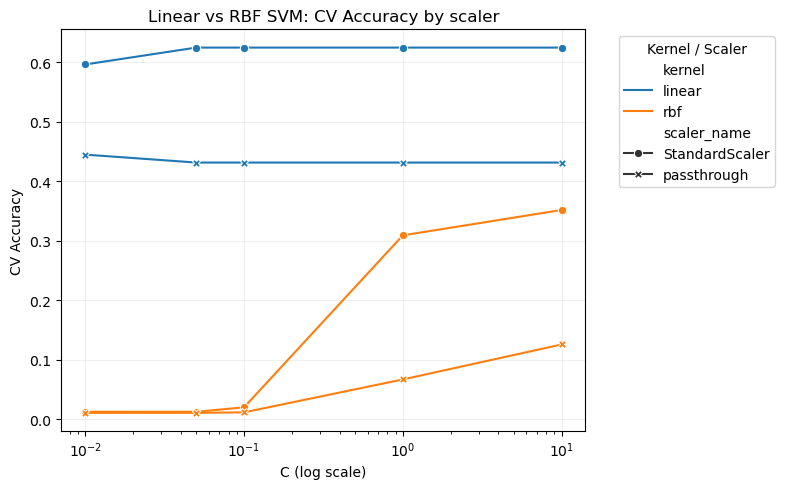


Best CV accuracy by kernel and scaler:
   kernel     scaler_name  mean_test_score
0  linear  StandardScaler         0.625000
2     rbf  StandardScaler         0.610000
1  linear     passthrough         0.445000
3     rbf     passthrough         0.358333


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


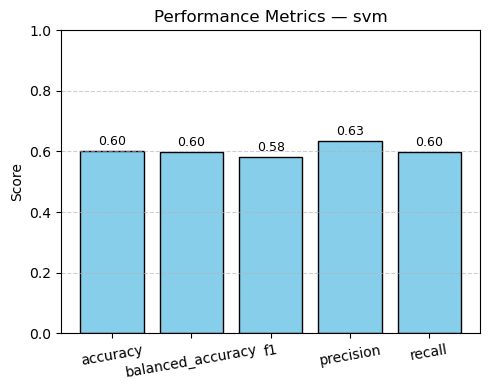


Classification report (test set) for best SVM:
              precision    recall  f1-score   support

     Agresti       0.67      0.67      0.67         3
   Ashbacher       1.00      0.50      0.67         2
       Auken       0.50      0.50      0.50         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.50      0.67      0.57         3
       Brown       0.33      0.67      0.44         3
    Bukowsky       0.33      0.33      0.33         3
         CFH       1.00      0.67      0.80         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.67      1.00      0.80         4
    Chandler       0.50      0.67      0.57         3
       Chell       0.20      0.25      0.22         4
    Cholette       0.50      0.67      0.57         3
      Comdet       0.50      0.50      0.50         4
        Corn       0.40      0.67      0.50         3
       Cutey       1.00      0.67      0.80         3
    Davisson       0.67      1.00

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [22]:
# Best feature + scaler diferences + hyperparameter tuning (RBF, linear)
#  Algorithm 2: Support Vector Machine (SVM) 
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)), # f_classif acc: 0.60
    ('svm', SVC(probability=True, random_state=42)) 
])


#  param grids (add scaler choice to both) 
param_grid_linear = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 100, 150, 170, 200, 500],
    'svm__kernel': ['linear'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10]
}

param_grid_rbf = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 100, 150, 170, 200, 500],
    'svm__kernel': ['rbf'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.05, 0.1]
}

print("\n Starting FINETUNED SVM Search (Linear + RBF) ")
# We pass the list of grids to the 'param_grid' argument
grid_svm = GridSearchCV(
    pipeline_svm,
    [param_grid_linear, param_grid_rbf],
    cv=kfold_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)
grid_svm.fit(X_train, y_train)
print("\n SVM Search Complete ")
print(f"Best SVM Score (CV Accuracy): {grid_svm.best_score_:.4f}")
print("Best SVM Parameters Found:")
print(grid_svm.best_params_)


#    extract cv results into DataFrame for plotting/analysis   
cv = pd.DataFrame(grid_svm.cv_results_)

cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
cv['C'] = cv['param_svm__C'].astype(float)
# gamma can be 'scale' or numeric -> convert to string for pivoting/labels
cv['gamma_str'] = cv['param_svm__gamma'].astype(str)
cv['kernel'] = cv['param_svm__kernel'].astype(str)
cv['selector_k'] = cv['param_selector__k'].astype(int)
cv['mean_test_score'] = cv['mean_test_score'].astype(float)

#  1) Best CV accuracy per scaler (overall, across kernels and other params) 
best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy per scaler (overall):")
print(best_per_scaler)

# bar plot: best per scaler
plt.figure(figsize=(5,4))
plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
plt.ylim(0,1)
plt.ylabel('CV Accuracy')
plt.title('Best CV Accuracy: StandardScaler vs passthrough (SVM)')
for i, v in enumerate(best_per_scaler['mean_test_score']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()

#  2) Linear kernel: accuracy vs C (one line per scaler) 
linear = cv[cv['kernel'] == 'linear'].copy()
if linear.shape[0] == 0:
    print("No linear-kernel runs found in cv results.")
else:
    # choose best mean_test_score across selector__k for each (scaler, C)
    agg_linear = linear.groupby(['scaler_name', 'C'])['mean_test_score'].max().unstack('scaler_name').sort_index()
    plt.figure(figsize=(7,4))
    for col in agg_linear.columns:
        plt.semilogx(agg_linear.index, agg_linear[col], marker='o', label=col)  # semilog for C
    plt.xlabel('C (log scale)')
    plt.ylabel('CV Accuracy')
    plt.title('Linear SVM: CV Accuracy vs C (by scaler)')
    plt.xticks(agg_linear.index, agg_linear.index)
    plt.grid(alpha=0.2)
    plt.legend(title='scaler')
    plt.show()
    print("\nLinear kernel: best accuracy by (scaler, C):")
    print(agg_linear.max().sort_values(ascending=False))

# heatmaps of accuracy by (gamma × C) for each scaler
rbf = cv[cv['kernel'] == 'rbf'].copy()
if rbf.shape[0] == 0:
    print("No RBF-kernel runs found in cv results.")
else:
    scalers = rbf['scaler_name'].unique()
    # create one heatmap per scaler
    for sc in scalers:
        df = rbf[rbf['scaler_name'] == sc]
        # pivot table: rows = gamma_str, cols = C
        pivot = df.groupby(['gamma_str', 'C'])['mean_test_score'].max().unstack(level=1)
        # sort columns by numeric C order
        pivot = pivot.reindex(columns=sorted(pivot.columns))
        # convert pivot to numpy matrix for imshow
        mat = pivot.values
        plt.figure(figsize=(8, 4 + 0.5 * len(pivot)))
        im = plt.imshow(mat, aspect='auto', vmin=0, vmax=1)
        plt.colorbar(im, label='CV Accuracy')
        plt.yticks(np.arange(len(pivot.index)), pivot.index)
        plt.xticks(np.arange(len(pivot.columns)), [str(c) for c in pivot.columns], rotation=45)
        plt.xlabel('C')
        plt.ylabel('gamma')
        plt.title(f'RBF SVM CV Accuracy (scaler={sc})\n(mean across selector__k; darker = higher)')
        # annotate numbers
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                if not np.isnan(val):
                    plt.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8, color='white' if val > 0.5 else 'black')
        plt.tight_layout()
        plt.show()

    # summary: best per (scaler, gamma, C)
    best_rbf = rbf.groupby(['scaler_name', 'gamma_str', 'C'])['mean_test_score'].max().reset_index()
    best_rbf_sorted = best_rbf.sort_values('mean_test_score', ascending=False).head(10)
    print("\nTop RBF configurations (scaler, gamma, C) by CV accuracy:")
    print(best_rbf_sorted)


linear_summary = cv[cv['kernel']=='linear'].groupby(['scaler_name','C'])['mean_test_score'].max().reset_index()
linear_summary['gamma_str'] = 'linear'
linear_summary['kernel'] = 'linear'
# RBF: best across selector__k, average across gamma
rbf_summary = cv[cv['kernel']=='rbf']
rbf_avg = rbf_summary.groupby(['scaler_name','C'])['mean_test_score'].mean().reset_index()
rbf_avg['kernel'] = 'rbf'
# Combine
compare_df = pd.concat([
    linear_summary.rename(columns={'mean_test_score':'CV Accuracy'}),
    rbf_avg.rename(columns={'mean_test_score':'CV Accuracy'})
], axis=0)
plt.figure(figsize=(8,5))
sns.lineplot(data=compare_df, x='C', y='CV Accuracy', hue='kernel', style='scaler_name', markers=True, dashes=False)
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('CV Accuracy')
plt.title('Linear vs RBF SVM: CV Accuracy by scaler')
plt.grid(alpha=0.2)
plt.legend(title='Kernel / Scaler', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()



#  4) summary by kernel + scaler 
best_by_kernel_scaler = cv.groupby(['kernel', 'scaler_name'])['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy by kernel and scaler:")
print(best_by_kernel_scaler)

#    final test-evaluation using the overall best estimator   
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

evaluation = evaluate_run(name='svm', y_true=y_test, y_pred=y_pred_svm, task_type='classification')
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)

print("\nClassification report (test set) for best SVM:")
print(classification_report(y_test, y_pred_svm))

wanted to do Recursive Feature Elimination, but realized that would take forever in case of 10k features -> check if there is threshold setting for this

# Decision Tree

not good for many features low sample size -> overfit on high dimensional data

In [23]:
def analyze_dt_grid(grid, title):
    cv = pd.DataFrame(grid.cv_results_)
    cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
    cv['max_depth_str'] = cv['param_dt__max_depth'].apply(lambda x: 'None' if pd.isna(x) else str(x))
    cv['max_depth_sort'] = cv['param_dt__max_depth'].apply(lambda x: np.inf if pd.isna(x) else float(x))
    cv['mean_test_score'] = cv['mean_test_score'].astype(float)

    # accuracy vs max_depth
    agg = cv.groupby(['scaler_name', 'max_depth_str', 'max_depth_sort'])['mean_test_score'].max().reset_index()
    agg = agg.sort_values(['scaler_name','max_depth_sort'])
    pivot = agg.pivot(index='max_depth_str', columns='scaler_name', values='mean_test_score')
    
    plt.figure(figsize=(7,4))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker='o', label=col)
    plt.xlabel('max_depth')
    plt.ylabel('CV Accuracy')
    plt.title(f'{title}: Accuracy vs max_depth')
    plt.legend(title='Scaler')
    plt.grid(alpha=0.2)
    plt.xticks(rotation=30)
    plt.show()
    
    return cv


=== Running GridSearch for SelectKBest ===
Fitting 10 folds for each of 480 candidates, totalling 4800 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Done SelectKBest search.
Best CV score: 0.3983333333333333
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 5, 'scaler': StandardScaler(), 'selector__k': 150}

=== Running GridSearch for SelectFromModel(RF) ===
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Done SelectFromModel search.
Best CV score: 0.32499999999999996
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 3, 'scaler': 'passthrough'}

=== Running GridSearch for Passthrough ===
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Done Passthrough search.
Best CV score: 0.33333333333333337
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 3, 'scaler': 'passthrough'}


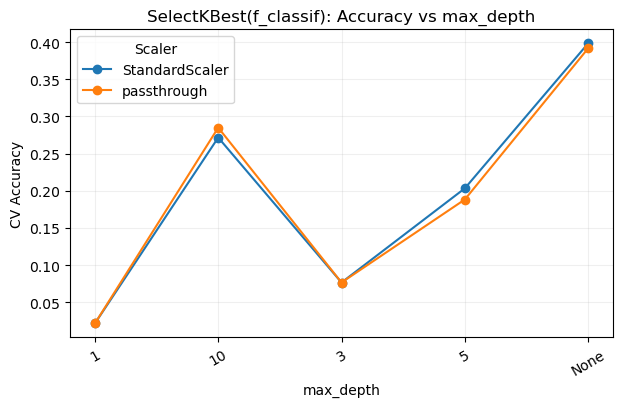

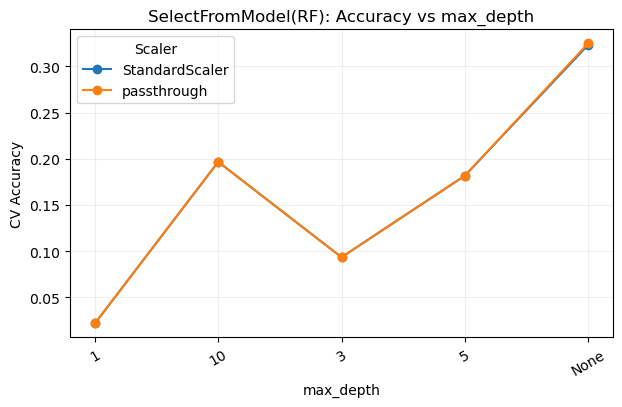

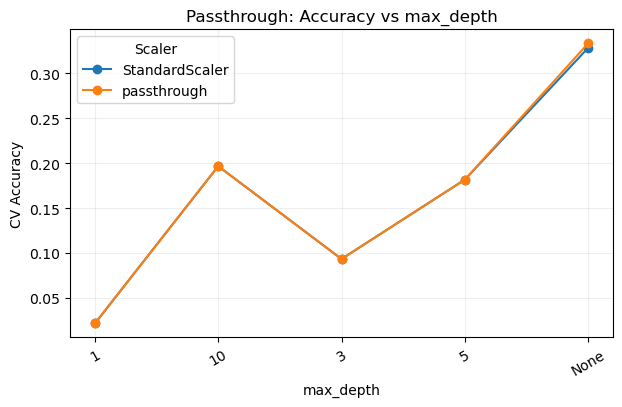


=== Test set evaluation for SelectKBest ===
Accuracy: 0.3467


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


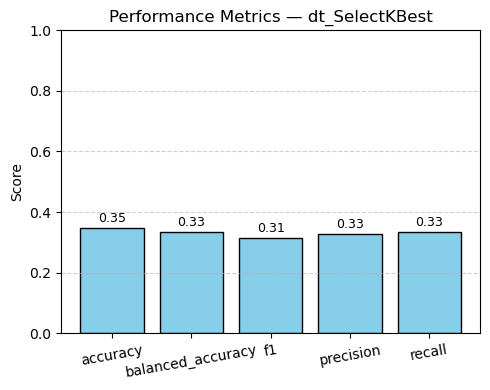


=== Test set evaluation for SelectFromModel_RF ===
Accuracy: 0.3467


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


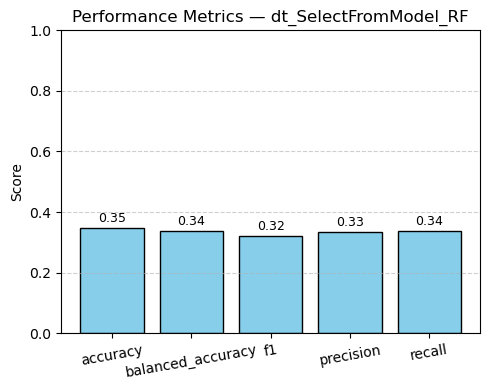


=== Test set evaluation for Passthrough ===
Accuracy: 0.3533


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


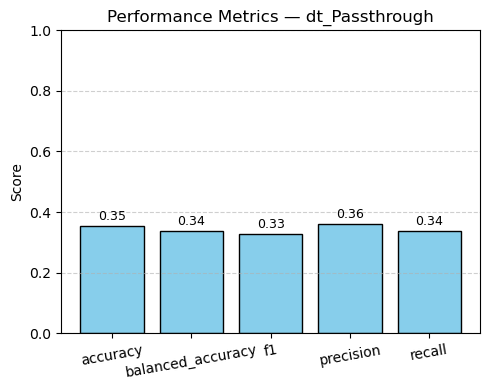

In [ ]:


# 1) Pipeline: SelectKBest(f_classif)
pipeline_skb = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_skb = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 75, 100, 125, 150, 200],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n   Running GridSearch for SelectKBest   ")
grid_skb = GridSearchCV(pipeline_skb, param_grid_skb, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_skb.fit(X_train, y_train)
print("Done SelectKBest search.")
print("Best CV score:", grid_skb.best_score_)
print("Best params:", grid_skb.best_params_)

# 2) Pipeline: SelectFromModel(RandomForest)
rf_for_sel = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
pipeline_sfm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(rf_for_sel, threshold='median')),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_sfm = {
    'scaler': [StandardScaler(), 'passthrough'],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n   Running GridSearch for SelectFromModel(RF)   ")
grid_sfm = GridSearchCV(pipeline_sfm, param_grid_sfm, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_sfm.fit(X_train, y_train)
print("Done SelectFromModel search.")
print("Best CV score:", grid_sfm.best_score_)
print("Best params:", grid_sfm.best_params_)

# 3) Pipeline: passthrough (no feature selection)
pipeline_pass = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', 'passthrough'),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_pass = {
    'scaler': [StandardScaler(), 'passthrough'],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n   Running GridSearch for Passthrough   ")
grid_pass = GridSearchCV(pipeline_pass, param_grid_pass, cv=kfold_cv,
                         scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_pass.fit(X_train, y_train)
print("Done Passthrough search.")
print("Best CV score:", grid_pass.best_score_)
print("Best params:", grid_pass.best_params_)


cv_skb = analyze_dt_grid(grid_skb, 'SelectKBest(f_classif)')
cv_sfm = analyze_dt_grid(grid_sfm, 'SelectFromModel(RF)')
cv_pass = analyze_dt_grid(grid_pass, 'Passthrough')

# final test evaluation
for name, grid in zip(['SelectKBest', 'SelectFromModel_RF', 'Passthrough'],
                      [grid_skb, grid_sfm, grid_pass]):
    best_dt = grid.best_estimator_
    y_pred = best_dt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n   Test set evaluation for {name}   ")
    print(f"Accuracy: {acc:.4f}")
    evaluation = evaluate_run(name=f'dt_{name}', y_true=y_test, y_pred=y_pred, task_type='classification')
    plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
    # print(classification_report(y_test, y_pred))



=== Running GridSearch for SelectKBest ===
Fitting 10 folds for each of 480 candidates, totalling 4800 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Done SelectKBest search.
Best CV score: 0.3983333333333333
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 5, 'scaler': StandardScaler(), 'selector__k': 150}

=== Running GridSearch for SelectFromModel(RF) ===
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Done SelectFromModel search.
Best CV score: 0.32499999999999996
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 3, 'scaler': 'passthrough'}

=== Running GridSearch for Passthrough ===
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Done Passthrough search.
Best CV score: 0.33333333333333337
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 3, 'scaler': 'passthrough'}


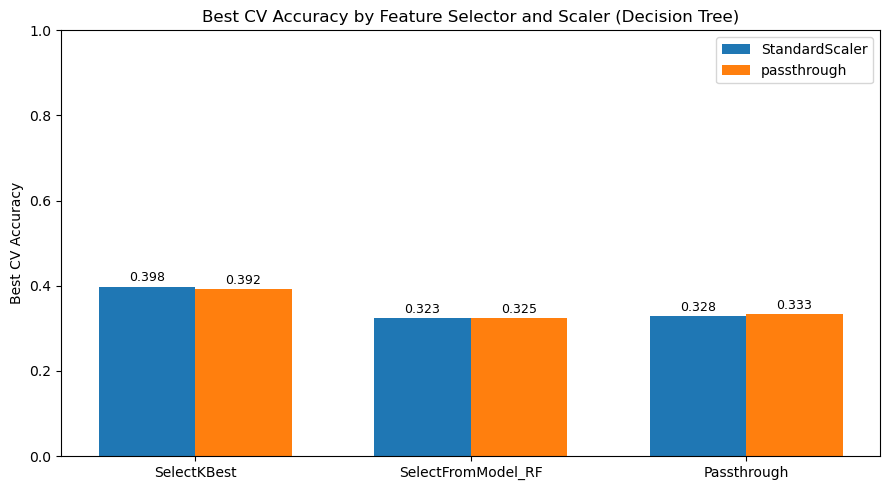

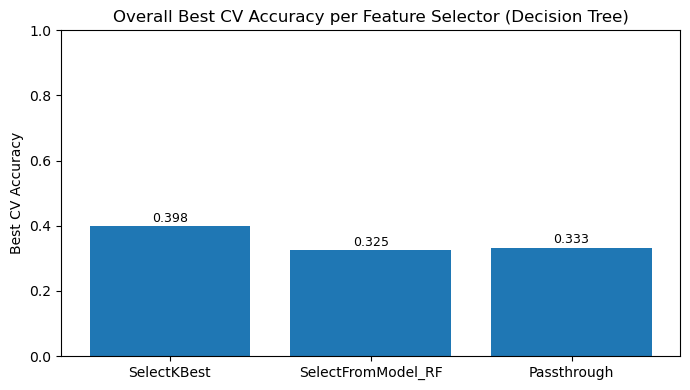

In [ ]:

# 1.pipeline: SelectKBest(f_classif)
pipeline_skb = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_skb = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 75, 100, 125, 150, 200],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n   Running GridSearch for SelectKBest   ")
grid_skb = GridSearchCV(pipeline_skb, param_grid_skb, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_skb.fit(X_train, y_train)
print("Done SelectKBest search.")
print("Best CV score:", grid_skb.best_score_)
print("Best params:", grid_skb.best_params_)


# 2. pipeline: SelectFromModel(RandomForest)
rf_for_sel = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
pipeline_sfm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(rf_for_sel, threshold='median')),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_sfm = {
    'scaler': [StandardScaler(), 'passthrough'],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n   Running GridSearch for SelectFromModel(RF)   ")
grid_sfm = GridSearchCV(pipeline_sfm, param_grid_sfm, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_sfm.fit(X_train, y_train)
print("Done SelectFromModel search.")
print("Best CV score:", grid_sfm.best_score_)
print("Best params:", grid_sfm.best_params_)


# 3. pipeline: passthrough (no feature selection)
pipeline_pass = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', 'passthrough'),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_pass = {
    'scaler': [StandardScaler(), 'passthrough'],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n   Running GridSearch for Passthrough   ")
grid_pass = GridSearchCV(pipeline_pass, param_grid_pass, cv=kfold_cv,
                         scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_pass.fit(X_train, y_train)
print("Done Passthrough search.")
print("Best CV score:", grid_pass.best_score_)
print("Best params:", grid_pass.best_params_)

# Helper function to extract best CV per scaler
def get_best_per_scaler(grid):
    cv = pd.DataFrame(grid.cv_results_)
    cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
    best = cv.groupby('scaler_name')['mean_test_score'].max().reset_index()
    return best.set_index('scaler_name')

best_skb_idx = get_best_per_scaler(grid_skb)
best_sfm_idx = get_best_per_scaler(grid_sfm)
best_pass_idx = get_best_per_scaler(grid_pass)

# Extract values (fill 0 if missing)
def get_val(idx_df, name):
    try:
        return float(idx_df.loc[name, 'mean_test_score'])
    except Exception:
        return 0.0

selectors = ['SelectKBest', 'SelectFromModel_RF', 'Passthrough']
std_vals = [get_val(best_skb_idx, 'StandardScaler'),
            get_val(best_sfm_idx, 'StandardScaler'),
            get_val(best_pass_idx, 'StandardScaler')]

passth_vals = [get_val(best_skb_idx, 'passthrough'),
               get_val(best_sfm_idx, 'passthrough'),
               get_val(best_pass_idx, 'passthrough')]

#  Combined grouped bar plot: selector × scaler 
x = np.arange(len(selectors))
width = 0.35
plt.figure(figsize=(9,5))
bars1 = plt.bar(x - width/2, std_vals, width, label='StandardScaler')
bars2 = plt.bar(x + width/2, passth_vals, width, label='passthrough')

plt.ylim(0,1)
plt.ylabel('Best CV Accuracy')
plt.title('Best CV Accuracy by Feature Selector and Scaler (Decision Tree)')
plt.xticks(x, selectors)
plt.legend()

for b in bars1 + bars2:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 0.005, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#  Simple overall best CV per selector 
overall_vals = [grid_skb.best_score_, grid_sfm.best_score_, grid_pass.best_score_]
plt.figure(figsize=(7,4))
bars = plt.bar(selectors, overall_vals)
plt.ylim(0,1)
plt.ylabel('Best CV Accuracy')
plt.title('Overall Best CV Accuracy per Feature Selector (Decision Tree)')

for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 0.005, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


